     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 64.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.3 which is incompatible.
✅ All 5 datasets loaded successfully:
 - Slots: (10, 8)
 - Zones: (3, 4)
 - Staff: (3, 5)
 - History: (1, 7)
 - Rules: (2, 3)
Enter your Groq API Key: ··········


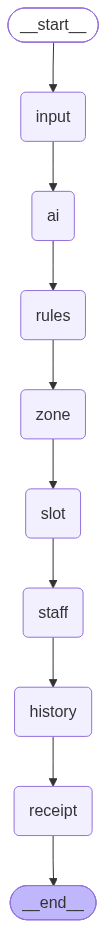


========== SMART PARKING REGISTRATION ==========
Enter Name: Soumyajit Rout
Vehicle Number: OD35 1122
Vehicle Type (Car/Bike/EV): Bike
Category (General/VIP/Disabled): General
Preferred Zone (A/B/C): B
Purpose: shopping

      SMART PARKING BOOKING RECEIPT
Customer        : Soumyajit Rout
Vehicle Number  : OD35 1122
Vehicle Type    : Bike
Category        : General
Assigned Zone   : B
Assigned Slot   : P004
Parking Staff   : Staff1
Priority        : Normal

             FINAL SUMMARY
Customer : Soumyajit Rout
Vehicle  : OD35 1122
Zone     : B
Slot     : P004
Staff    : Staff1
Status   : SUCCESS


/tmp/ipykernel_1701/4088375247.py:336: Pandas4Warning: The copy keyword is deprecated and will be removed in a future version. Copy-on-Write is active in pandas since 3.0 which utilizes a lazy copy mechanism that defers copies until necessary. Use .copy() to make an eager copy if necessary.
  zones_df.set_index("Zone")[["Available", "Occupied"]].plot(
/tmp/ipykernel_1701/4088375247.py:346: Pandas4Warning: The copy keyword is deprecated and will be removed in a future version. Copy-on-Write is active in pandas since 3.0 which utilizes a lazy copy mechanism that defers copies until necessary. Use .copy() to make an eager copy if necessary.
  type_counts.plot(kind="pie", ax=axes[1], autopct="%1.1f%%", startangle=90, colors=['#1f77b4', '#ff7f0e', '#2ca02c'])


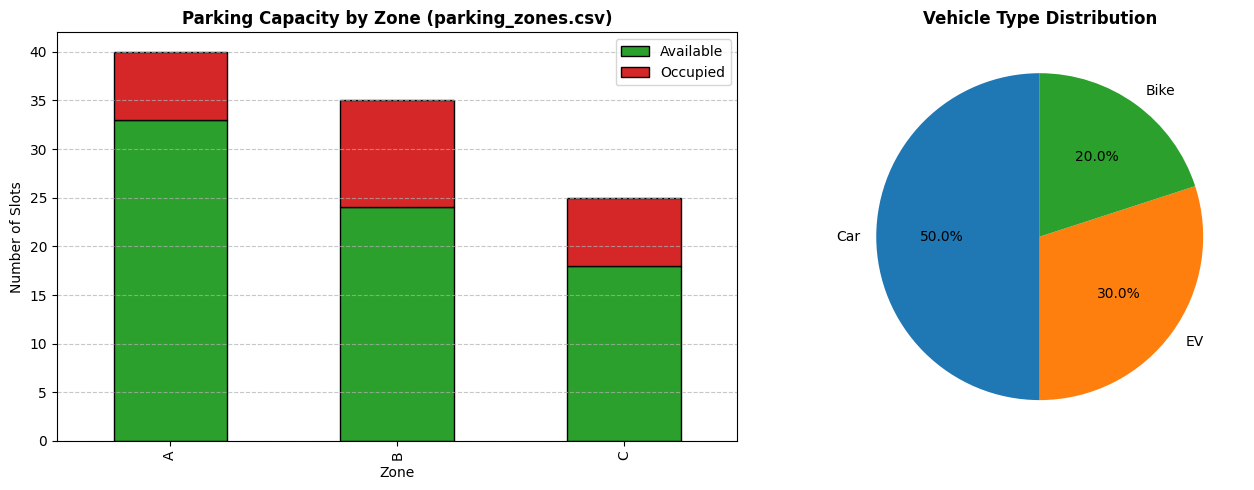

In [ ]:
# ==============================================================================
# AI Smart Parking Management & Intelligent Slot Allocation System
# IBM SkillsBuild Internship Project | SDG 11: Sustainable Cities & Communities
# ==============================================================================

# Step 1: Install required dependencies
!pip install -qU langgraph langchain-groq pandas matplotlib openpyxl
!pip install -qU "pandas<3.0.0" langgraph langchain-groq matplotlib openpyxl

import os
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
from getpass import getpass
from typing import TypedDict
from IPython.display import display, Image

from langgraph.graph import StateGraph, END
from langchain_groq import ChatGroq
from langchain_core.messages import SystemMessage, HumanMessage

# ==============================================================================
# Step 2: Auto-Setup All 5 Datasets (Ensures Code Runs Error-Free)
# ==============================================================================
def setup_datasets():
    if not os.path.exists("parking_slots.csv"):
        slots_data = {
            "Slot_ID": [f"P{i:03d}" for i in range(1, 11)],
            "Zone": ["A", "A", "A", "B", "B", "B", "C", "C", "C", "C"],
            "Floor": [1, 1, 2, 1, 1, 2, 1, 1, 2, 2],
            "Vehicle_Type": ["Car", "EV", "Bike", "Car", "EV", "Car", "Bike", "Car", "EV", "Car"],
            "EV_Charging": ["No", "Yes", "No", "No", "Yes", "No", "No", "No", "Yes", "No"],
            "Reserved_For": ["General", "EV", "Disabled", "VIP", "EV", "General", "General", "General", "EV", "General"],
            "Distance": [10, 15, 20, 5, 12, 25, 8, 18, 22, 30],
            "Status": ["Free", "Free", "Free", "Free", "Free", "Free", "Free", "Free", "Free", "Free"]
        }
        pd.DataFrame(slots_data).to_csv("parking_slots.csv", index=False)

    if not os.path.exists("parking_zones.csv"):
        zones_data = {
            "Zone": ["A", "B", "C"],
            "Total_Slots": [40, 35, 25],
            "Available": [33, 25, 18],
            "Occupied": [7, 10, 7]
        }
        pd.DataFrame(zones_data).to_csv("parking_zones.csv", index=False)

    if not os.path.exists("parking_staff.csv"):
        staff_data = {
            "Staff_ID": ["ST001", "ST002", "ST003"],
            "Name": ["Staff1", "Staff2", "Staff3"],
            "Role": ["Security", "Security", "Attendant"],
            "Shift": ["Night", "Evening", "Morning"],
            "Status": ["Available", "Available", "Available"]
        }
        pd.DataFrame(staff_data).to_csv("parking_staff.csv", index=False)

    if not os.path.exists("parking_history.csv"):
        history_data = {
            "Booking_ID": ["B001"],
            "Vehicle_No": ["OD30XY2728"],
            "Slot_ID": ["P052"],
            "Zone": ["A"],
            "Entry_Time": ["09:00"],
            "Exit_Time": ["11:00"],
            "Fee": [40]
        }
        pd.DataFrame(history_data).to_csv("parking_history.csv", index=False)

    if not os.path.exists("parking_rules.csv"):
        rules_data = {
            "Rule_ID": ["R001", "R002"],
            "Condition": ["EV Vehicle", "VIP User"],
            "Action": ["Assign EV Charging Slot", "Assign VIP Slot"]
        }
        pd.DataFrame(rules_data).to_csv("parking_rules.csv", index=False)

setup_datasets()

# Load DataFrames
slots_df = pd.read_csv("parking_slots.csv")
zones_df = pd.read_csv("parking_zones.csv")
staff_df = pd.read_csv("parking_staff.csv")
history_df = pd.read_csv("parking_history.csv")
rules_df = pd.read_csv("parking_rules.csv")

print("✅ All 5 datasets loaded successfully:")
print(" - Slots:", slots_df.shape)
print(" - Zones:", zones_df.shape)
print(" - Staff:", staff_df.shape)
print(" - History:", history_df.shape)
print(" - Rules:", rules_df.shape)

# ==============================================================================
# Step 3: Set Groq API Key
# ==============================================================================
if "GROQ_API_KEY" not in os.environ or not os.environ["GROQ_API_KEY"]:
    os.environ["GROQ_API_KEY"] = getpass("Enter your Groq API Key: ")

llm = ChatGroq(model="llama-3.3-70b-versatile", temperature=0)

PARKING_SYSTEM_PROMPT = """
You are an AI Smart Parking Assistant.
Analyze the user's parking request and return ONLY JSON with keys:
{
 "priority": "HIGH/Normal",
 "recommended_zone": "A/B/C",
 "parking_type": "EV/VIP/Disabled/General",
 "reason": "<brief reasoning>"
}

Rules:
1. EV vehicles -> EV Parking
2. VIP users -> VIP Parking
3. Disabled users -> Disabled Parking
4. General users -> General Parking
5. If preferred zone is full, recommend nearest available zone.
"""

# ==============================================================================
# Step 4: Define LangGraph State & Node Functions
# ==============================================================================
class ParkingState(TypedDict):
    name: str
    vehicle_number: str
    vehicle_type: str
    category: str
    preferred_zone: str
    purpose: str
    assigned_zone: str
    assigned_slot: str
    assigned_staff: str
    priority: str
    parking_type: str
    reasoning: str
    booking_status: str

def input_node(state: ParkingState) -> ParkingState:
    print("\n========== SMART PARKING REGISTRATION ==========")
    name = input("Enter Name: ").strip() or "User1"
    vehicle_number = input("Vehicle Number: ").strip() or "OD40AB2420"
    vehicle_type = input("Vehicle Type (Car/Bike/EV): ").strip().title() or "EV"
    category = input("Category (General/VIP/Disabled): ").strip().title() or "General"
    preferred_zone = input("Preferred Zone (A/B/C): ").strip().upper() or "C"
    purpose = input("Purpose: ").strip() or "Hospital"

    return {
        "name": name,
        "vehicle_number": vehicle_number,
        "vehicle_type": vehicle_type,
        "category": category,
        "preferred_zone": preferred_zone,
        "purpose": purpose,
        "assigned_zone": "",
        "assigned_slot": "",
        "assigned_staff": "",
        "priority": "Normal",
        "parking_type": "General",
        "reasoning": "",
        "booking_status": "PENDING"
    }

def ai_analysis_node(state: ParkingState) -> ParkingState:
    msg = f"""
    Vehicle Type: {state['vehicle_type']}
    Category: {state['category']}
    Preferred Zone: {state['preferred_zone']}
    Purpose: {state['purpose']}
    """
    response = llm.invoke([
        SystemMessage(content=PARKING_SYSTEM_PROMPT),
        HumanMessage(content=msg)
    ])
    state["reasoning"] = response.content
    return state

def rule_engine_node(state: ParkingState) -> ParkingState:
    if state["vehicle_type"] == "EV":
        state["parking_type"] = "EV"
        state["priority"] = "HIGH"
    elif state["category"] == "VIP":
        state["parking_type"] = "VIP"
        state["priority"] = "HIGH"
    elif state["category"] == "Disabled":
        state["parking_type"] = "Disabled"
        state["priority"] = "HIGH"
    else:
        state["parking_type"] = "General"
        state["priority"] = "Normal"
    return state

def zone_selection_node(state: ParkingState) -> ParkingState:
    zone = state["preferred_zone"]

    # Check zone availability from zones_df
    zone_data = zones_df[zones_df["Zone"] == zone]
    if not zone_data.empty and zone_data.iloc[0]["Available"] > 0:
        state["assigned_zone"] = zone
    else:
        # Find zone with most available slots
        avail_zones = zones_df[zones_df["Available"] > 0].sort_values("Available", ascending=False)
        if not avail_zones.empty:
            state["assigned_zone"] = avail_zones.iloc[0]["Zone"]
        else:
            state["assigned_zone"] = "FULL"

    return state

def slot_allocation_node(state: ParkingState) -> ParkingState:
    if state["assigned_zone"] == "FULL":
        state["assigned_slot"] = "NONE"
        return state

    available = slots_df[(slots_df["Zone"] == state["assigned_zone"]) & (slots_df["Status"] == "Free")]

    if available.empty:
        available = slots_df[slots_df["Status"] == "Free"]

    if not available.empty:
        available = available.sort_values("Distance")
        slot = available.iloc[0]
        state["assigned_slot"] = slot["Slot_ID"]

        # Update slots dataframe
        slots_df.loc[slots_df["Slot_ID"] == slot["Slot_ID"], "Status"] = "Occupied"

        # Update zones dataframe
        z_idx = zones_df["Zone"] == state["assigned_zone"]
        if zones_df.loc[z_idx, "Available"].values[0] > 0:
            zones_df.loc[z_idx, "Available"] -= 1
            zones_df.loc[z_idx, "Occupied"] += 1
    else:
        state["assigned_slot"] = "NONE"

    return state

def staff_node(state: ParkingState) -> ParkingState:
    available_staff = staff_df[staff_df["Status"] == "Available"]
    if not available_staff.empty:
        person = available_staff.iloc[0]
        state["assigned_staff"] = person["Name"]
        staff_df.loc[staff_df["Name"] == person["Name"], "Status"] = "Busy"
    else:
        state["assigned_staff"] = "Auto-System"
    return state

def history_node(state: ParkingState) -> ParkingState:
    global history_df
    new_booking = {
        "Booking_ID": f"B{len(history_df)+1:03d}",
        "Vehicle_No": state["vehicle_number"],
        "Slot_ID": state["assigned_slot"],
        "Zone": state["assigned_zone"],
        "Entry_Time": datetime.now().strftime("%Y-%m-%d %H:%M"),
        "Exit_Time": "",
        "Fee": 0
    }
    history_df = pd.concat([history_df, pd.DataFrame([new_booking])], ignore_index=True)

    # Export updated files
    history_df.to_csv("parking_history.csv", index=False)
    slots_df.to_csv("parking_slots.csv", index=False)
    zones_df.to_csv("parking_zones.csv", index=False)
    staff_df.to_csv("parking_staff.csv", index=False)
    return state

def receipt_node(state: ParkingState) -> ParkingState:
    print("\n" + "="*45)
    print("      SMART PARKING BOOKING RECEIPT")
    print("="*45)
    print(f"Customer        : {state['name']}")
    print(f"Vehicle Number  : {state['vehicle_number']}")
    print(f"Vehicle Type    : {state['vehicle_type']}")
    print(f"Category        : {state['category']}")
    print(f"Assigned Zone   : {state['assigned_zone']}")
    print(f"Assigned Slot   : {state['assigned_slot']}")
    print(f"Parking Staff   : {state['assigned_staff']}")
    print(f"Priority        : {state['priority']}")
    print("="*45)

    state["booking_status"] = "SUCCESS" if state["assigned_slot"] != "NONE" else "FAILED (FULL)"
    return state

# ==============================================================================
# Step 5: Build and Compile LangGraph Workflow
# ==============================================================================
builder = StateGraph(ParkingState)

builder.add_node("input", input_node)
builder.add_node("ai", ai_analysis_node)
builder.add_node("rules", rule_engine_node)
builder.add_node("zone", zone_selection_node)
builder.add_node("slot", slot_allocation_node)
builder.add_node("staff", staff_node)
builder.add_node("history", history_node)
builder.add_node("receipt", receipt_node)

builder.set_entry_point("input")
builder.add_edge("input", "ai")
builder.add_edge("ai", "rules")
builder.add_edge("rules", "zone")
builder.add_edge("zone", "slot")
builder.add_edge("slot", "staff")
builder.add_edge("staff", "history")
builder.add_edge("history", "receipt")
builder.add_edge("receipt", END)

graph = builder.compile()

# Visualize Graph Structure
try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    print("Graph compiled successfully!")

# ==============================================================================
# Step 6: Execute Workflow & Display Analytics Dashboard
# ==============================================================================
final_state = graph.invoke({})

print("\n" + "="*40)
print("             FINAL SUMMARY")
print("="*40)
print(f"Customer : {final_state['name']}")
print(f"Vehicle  : {final_state['vehicle_number']}")
print(f"Zone     : {final_state['assigned_zone']}")
print(f"Slot     : {final_state['assigned_slot']}")
print(f"Staff    : {final_state['assigned_staff']}")
print(f"Status   : {final_state['booking_status']}")
print("="*40)

# Display Analytics Dashboard
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1: Zone Capacity Status from zones_df
zones_df.set_index("Zone")[["Available", "Occupied"]].plot(
    kind="bar", stacked=True, ax=axes[0], color=['#2ca02c', '#d62728'], edgecolor='black'
)
axes[0].set_title("Parking Capacity by Zone (parking_zones.csv)", fontsize=12, fontweight='bold')
axes[0].set_ylabel("Number of Slots")
axes[0].set_xlabel("Zone")
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# Chart 2: Vehicle Type Distribution from slots_df
type_counts = slots_df["Vehicle_Type"].value_counts()
type_counts.plot(kind="pie", ax=axes[1], autopct="%1.1f%%", startangle=90, colors=['#1f77b4', '#ff7f0e', '#2ca02c'])
axes[1].set_title("Vehicle Type Distribution", fontsize=12, fontweight='bold')
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()